# Model 2: Holt-Winters Exponential Smoothing (ETS) for Drug `M01AB`

## Workflow Checklist:
1. **Pre-Training Suitability Checks**: Verify level, trend drift (+4.2%), and weekly seasonality ($m=7$).
2. **Model Formulation**: Test additive vs multiplicative trend/seasonality combinations.
3. **Fit on TRAIN (2014–2017)**: Estimate smoothing parameters ($lpha, eta, \gamma$) via MLE.
4. **Validate on 2018 Validation**: Evaluate Val RMSLE.
5. **Refit & Forecast 2019 Test**: Evaluate final holdout metrics.


In [1]:
import os
import sys
import warnings
import subprocess

# Auto-Dependency Guard: Check and install missing packages dynamically
pkg_map = {
    'prophet': 'prophet',
    'statsmodels': 'statsmodels',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
    'shap': 'shap',
    'torch': 'torch',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn'
}

missing = []
for mod_name, pip_name in pkg_map.items():
    try:
        __import__(mod_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Installing missing dependencies: {missing}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
        print("Dependencies successfully installed!")
    except Exception as err:
        print(f"Warning: Auto-pip install notice ({err}). Proceeding with environment packages...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

TARGET_DRUG = 'M01AB'

# Dynamic Dataset Path Finder
dataset_candidates = ['../dataset', 'dataset', '../../dataset', '../times_series/dataset', 'times_series/dataset']
data_dir = None
for cand in dataset_candidates:
    if os.path.exists(os.path.join(cand, 'train_daily.csv')):
        data_dir = cand
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate train_daily.csv dataset")

train_df = pd.read_csv(os.path.join(data_dir, 'train_daily.csv'))
val_df = pd.read_csv(os.path.join(data_dir, 'val_daily.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_daily.csv'))

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'])

train_series = train_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
val_series = val_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
test_series = test_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')

combined_series = pd.concat([train_series, val_series]).asfreq('D')
full_series = pd.concat([combined_series, test_series]).asfreq('D')

def evaluate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.clip(np.array(y_pred), 0, None)
    
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))
    return {'RMSLE': rmsle, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'WAPE (%)': wape}

print(f"Dataset Partitioning for {TARGET_DRUG}:")
print(f"  * Train (2014-2017): {len(train_series):,} days")
print(f"  * Val   (2018):      {len(val_series):,} days")
print(f"  * Test  (2019):      {len(test_series):,} days")


Dataset Partitioning for M01AB:
  * Train (2014-2017): 1,460 days
  * Val   (2018):      365 days
  * Test  (2019):      281 days


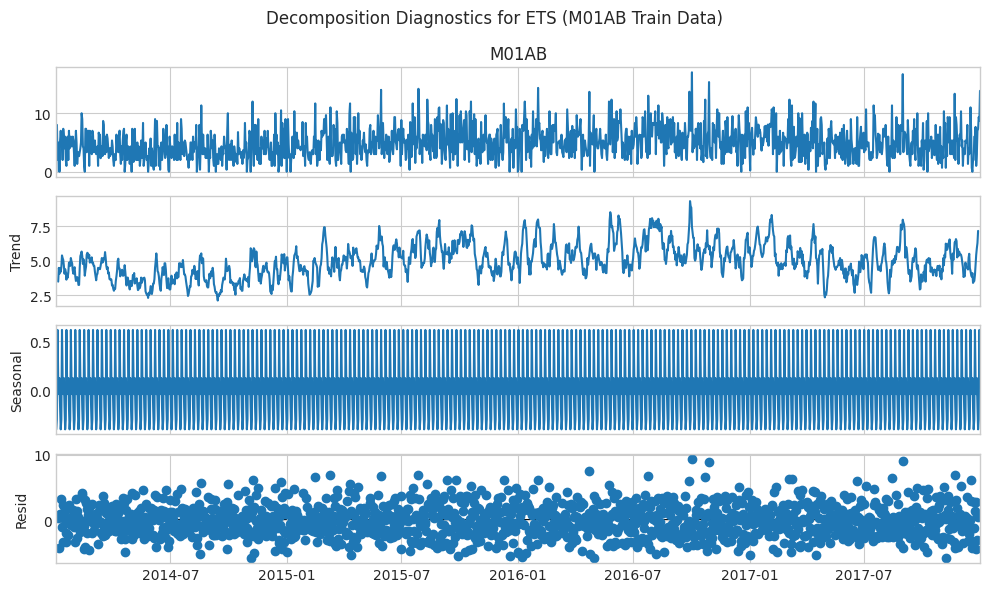

In [2]:
# Step 1: Pre-Training Suitability Checks
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(train_series, model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(10, 6)
plt.suptitle("Decomposition Diagnostics for ETS (M01AB Train Data)", fontsize=12)
plt.tight_layout()
plt.show()


In [3]:
# Step 2: Model Training on TRAIN (2014-2017) & Validation on 2018
from statsmodels.tsa.holtwinters import ExponentialSmoothing

m2_tr = ExponentialSmoothing(train_series, trend='add', seasonal='add', seasonal_periods=7).fit()

m2_val_pred = np.clip(m2_tr.forecast(steps=len(val_series)), 0, None)
val_metrics = evaluate_metrics(val_series, m2_val_pred)

print(f"Validation Metrics (2018) for Holt-Winters ETS:")
for k, v in val_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")


Validation Metrics (2018) for Holt-Winters ETS:
  * RMSLE     : 0.5637
  * RMSE      : 2.7580
  * MAE       : 2.2252
  * MAPE (%)  : 89.6780
  * WAPE (%)  : 45.4520


In [4]:
# Step 3: Refit on Train+Val & Forecast 2019 Test Holdout
m2_full = ExponentialSmoothing(combined_series, trend='add', seasonal='add', seasonal_periods=7).fit()

m2_test_pred = np.clip(m2_full.forecast(steps=len(test_series)), 0, None)
test_metrics = evaluate_metrics(test_series, m2_test_pred)

print(f"=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 2: HOLT-WINTERS ETS ===")
for k, v in test_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")

pd.DataFrame({'date': test_series.index, 'pred_ETS': m2_test_pred.values}).to_csv('m2_ets_preds.csv', index=False)


=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 2: HOLT-WINTERS ETS ===
  * RMSLE     : 0.5091
  * RMSE      : 2.8252
  * MAE       : 2.1928
  * MAPE (%)  : 76.1053
  * WAPE (%)  : 40.6116
